# M3 · Experiment 4 — Does funding-rate carry still pay?

E1-E3 were all *price bets*. They differed in which way they bet (trend, mean-revert, hold) but they all live or die on price action.

**Funding-rate arbitrage is structurally different.** A perpetual swap charges a periodic *funding* payment between longs and shorts to keep the perp price near spot. When the market is leaning long (bull market sentiment), longs pay shorts. The classic carry trade:

  - **Long spot BTC** + **short BTC/USDT perp** (delta-neutral)
  - Spot price moves cancel between the two legs
  - You collect the funding payments

Theoretically this earns money *regardless* of which way BTC moves. It's the closest thing in crypto to a risk-free rate.

## Research questions

1. What does the BTC perp funding rate actually look like over 2024-01 → 2025-12? Is it mostly positive?
2. What's the *gross* annualized harvest if I were continuously short the perp?
3. After realistic frictions (fees, capital tied up in two legs, leverage decisions), what's the net APR?
4. Is the trade decaying? Compare 2024 H1 vs 2025 H2.
5. How does it compare to buy-and-hold? (apples-to-oranges, but instructive)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hindcast.config import settings
from hindcast.data.storage import Storage

storage = Storage(settings.db_path)
START = pd.Timestamp('2024-01-01', tz='UTC')
END = pd.Timestamp('2026-01-01', tz='UTC')

funding = storage.query_funding_rate('binance', 'BTC/USDT:USDT', start=START, end=END).copy()
spot = storage.query_ohlcv('binance', 'BTC/USDT', '1d', start=START, end=END).copy()

funding['timestamp'] = pd.to_datetime(funding['timestamp'])
spot['timestamp'] = pd.to_datetime(spot['timestamp'])
print(f'funding events: {len(funding):,} (covers {funding["timestamp"].min().date()} to {funding["timestamp"].max().date()})')
print(f'spot bars     : {len(spot):,}')
print(f'binance USDM funding cadence: every 8h → {len(funding) / ((END - START).days):.2f} events/day on average')

funding events: 2,193 (covers 2024-01-01 to 2026-01-01)
spot bars     : 731
binance USDM funding cadence: every 8h → 3.00 events/day on average


## 1. The funding rate over time

Per-8h rate plotted alongside BTC price. Positive rate = longs pay shorts (the dominant regime in bull markets). Negative = shorts pay longs (rare in this sample, common in bears or local panics).

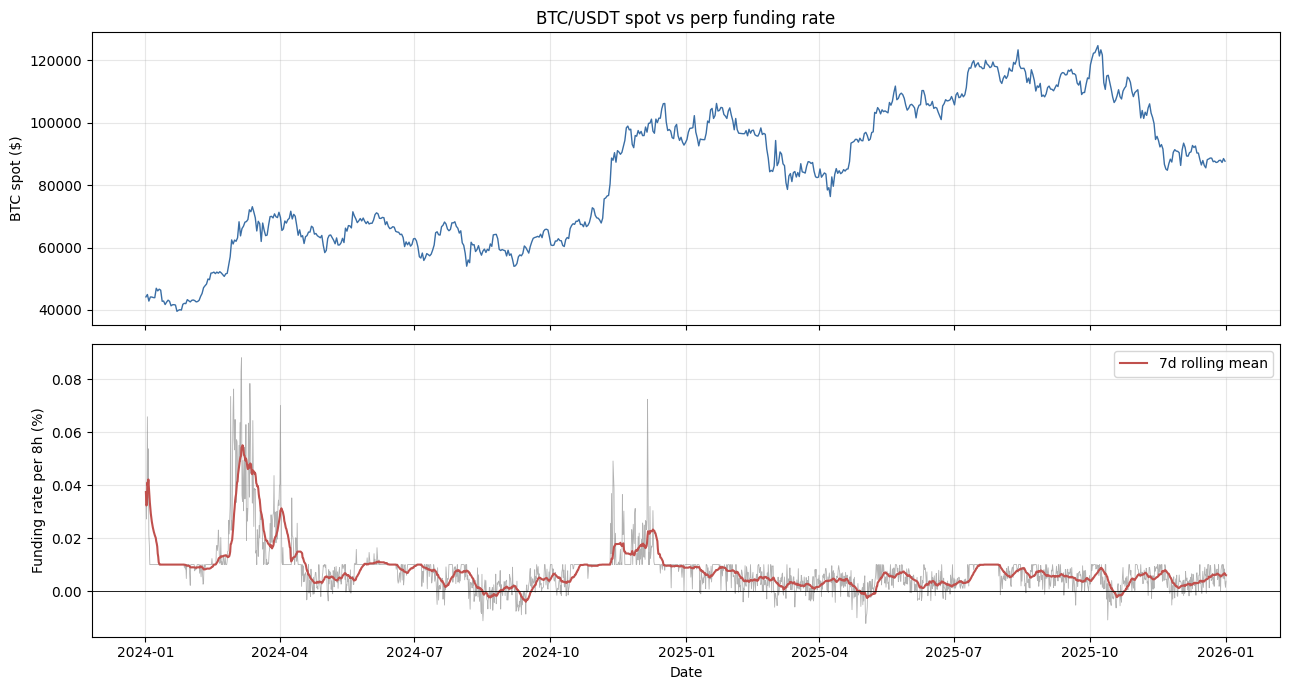

Share of intervals with positive funding (longs pay shorts): 89.38%
Share with negative funding:                                  10.62%
Share with exactly zero:                                      0.00%


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(spot['timestamp'], spot['close'], color='#3a6ea5', linewidth=1.0)
axes[0].set_ylabel('BTC spot ($)')
axes[0].set_title('BTC/USDT spot vs perp funding rate')
axes[0].grid(alpha=0.3)

axes[1].plot(funding['timestamp'], funding['rate'] * 100, color='gray', linewidth=0.6, alpha=0.6)
# 7-day rolling average for readability
fr = funding.set_index('timestamp')['rate'] * 100
axes[1].plot(fr.index, fr.rolling('7D').mean(), color='#c0504d', linewidth=1.5, label='7d rolling mean')
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('Funding rate per 8h (%)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

pos_share = (funding['rate'] > 0).mean()
print(f'Share of intervals with positive funding (longs pay shorts): {pos_share:.2%}')
print(f'Share with negative funding:                                  {(funding["rate"] < 0).mean():.2%}')
print(f'Share with exactly zero:                                      {(funding["rate"] == 0).mean():.2%}')

## 2. Distribution and gross APR

If I had been continuously short the perp at $10,000 notional and rebalanced to maintain that notional after every funding event, what would my cumulative funding cash be?

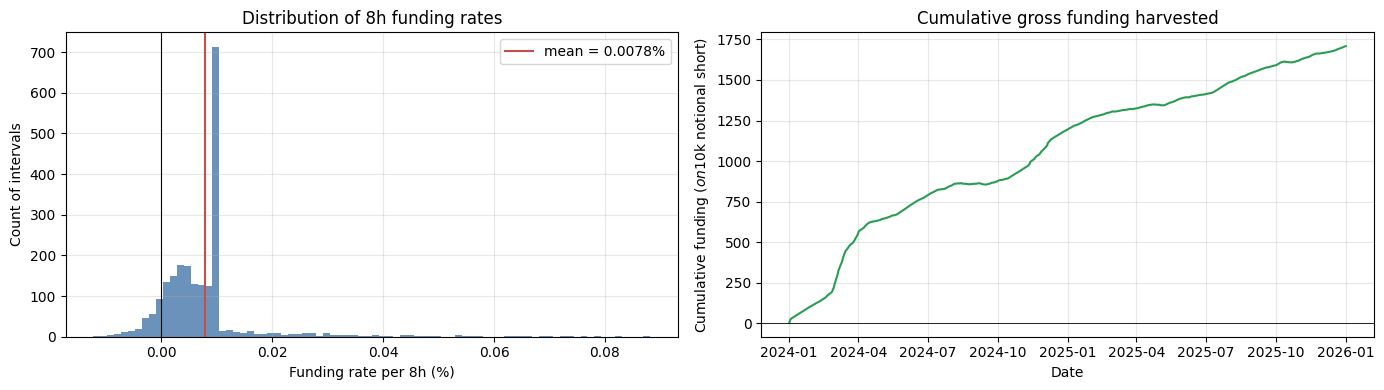

period: 731 days (2.00 years)
mean rate per 8h:    0.0078%
median rate per 8h:  0.0074%
cumulative cash:     $1,708.33 (on $10k notional)
gross APR (on notional): 8.54%


In [3]:
NOTIONAL = 10_000.0
f = funding.sort_values('timestamp').reset_index(drop=True)

# Cash collected per funding event, in USD on a fixed 10k notional short.
f['cash'] = NOTIONAL * f['rate']  # positive = received, negative = paid
f['cumulative'] = f['cash'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(f['rate'] * 100, bins=80, color='#3a6ea5', alpha=0.75)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline(f['rate'].mean() * 100, color='#c0504d', linewidth=1.5, label=f'mean = {f["rate"].mean()*100:.4f}%')
axes[0].set_xlabel('Funding rate per 8h (%)')
axes[0].set_ylabel('Count of intervals')
axes[0].set_title('Distribution of 8h funding rates')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(f['timestamp'], f['cumulative'], color='#2a9d54', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative funding $ (on $10k notional short)')
axes[1].set_title('Cumulative gross funding harvested')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

duration_days = (f['timestamp'].iloc[-1] - f['timestamp'].iloc[0]).total_seconds() / 86400
duration_years = duration_days / 365.25
total_cash = f['cumulative'].iloc[-1]
gross_apr_on_notional = (total_cash / NOTIONAL) / duration_years
print(f'period: {duration_days:.0f} days ({duration_years:.2f} years)')
print(f'mean rate per 8h:    {f["rate"].mean() * 100:.4f}%')
print(f'median rate per 8h:  {f["rate"].median() * 100:.4f}%')
print(f'cumulative cash:     ${total_cash:,.2f} (on $10k notional)')
print(f'gross APR (on notional): {gross_apr_on_notional:.2%}')

## 3. Net APR — what realistic frictions do to it

The gross number above is on *notional*. But the actual capital required to put on the trade is more. Three scenarios:

| Scenario | Spot leg | Perp margin | Total capital |
|----------|----------|-------------|---------------|
| **Conservative** (no perp leverage) | $10,000 | $10,000 | **$20,000** |
| **Mid** (3x perp leverage)          | $10,000 | $3,333  | **$13,333**   |
| **Aggressive** (5x perp leverage)   | $10,000 | $2,000  | **$12,000**   |

Round-trip fees (assume taker on both legs):
- Spot: 0.10% × $10k × 2 (in/out) = $20
- Perp: 0.04% × $10k × 2 (in/out) = $8
- **Total fees: $28** over the full period

Higher leverage = better capital efficiency but liquidation risk if perp moves against you between funding events. The 5x case in particular is jumpy.

In [4]:
FEES_TOTAL = 28.0
net_cash = total_cash - FEES_TOTAL

scenarios = {
    'Conservative (1x perp, $20k capital)': 20_000,
    'Mid (3x perp, $13.3k capital)':         13_333,
    'Aggressive (5x perp, $12k capital)':    12_000,
}
rows = []
for name, capital in scenarios.items():
    apr = (net_cash / capital) / duration_years
    rows.append({
        'scenario': name,
        'capital_$': capital,
        'net_cash_$': round(net_cash, 2),
        'period_return': f'{(net_cash / capital):+.2%}',
        'net_apr': f'{apr:+.2%}',
    })
pd.DataFrame(rows).set_index('scenario')

,capital_$,net_cash_$,period_return,net_apr
scenario,,,,
"Conservative (1x perp, $20k capital)",20000,1680.33,+8.40%,+4.20%
"Mid (3x perp, $13.3k capital)",13333,1680.33,+12.60%,+6.30%
"Aggressive (5x perp, $12k capital)",12000,1680.33,+14.00%,+7.00%


## 4. Is the trade decaying?

Funding rates respond to crowdedness. The more capital chases the carry, the more funding compresses toward zero. To check whether 2025 funding was lower than 2024:

=== Funding rate by quarter (BTC/USDT:USDT) ===
         mean_per_8h_%  annualized_%  count
quarter                                    
2024Q1          0.0203       22.2505    272
2024Q2          0.0086        9.4622    273
2024Q3          0.0032        3.4610    276
2024Q4          0.0116       12.6496    276
2025Q1          0.0048        5.2801    270
2025Q2          0.0032        3.5323    273
2025Q3          0.0064        7.0327    276
2025Q4          0.0043        4.6714    276
2026Q1          0.0038        4.1062      1


/var/folders/q8/3q72g1t155s1w33frqgflmqw0000gn/T/ipykernel_40552/3330902248.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  f['quarter'] = f['timestamp'].dt.to_period('Q')


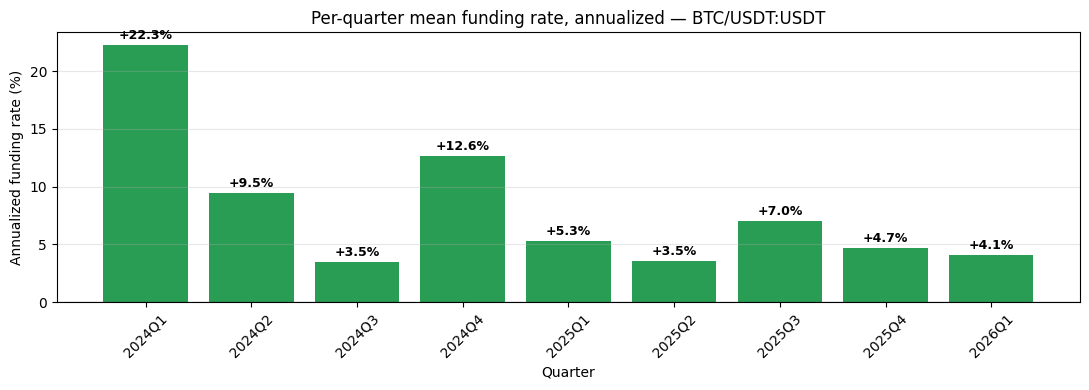

In [5]:
f['quarter'] = f['timestamp'].dt.to_period('Q')
by_q = f.groupby('quarter')['rate'].agg(['mean', 'median', 'count'])
by_q['mean_per_8h_%'] = by_q['mean'] * 100
by_q['annualized_%'] = by_q['mean'] * 1095 * 100  # 3 events/day * 365
print('=== Funding rate by quarter (BTC/USDT:USDT) ===')
print(by_q[['mean_per_8h_%', 'annualized_%', 'count']].round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    [str(q) for q in by_q.index],
    by_q['annualized_%'].values,
    color=['#2a9d54' if v > 0 else '#c0504d' for v in by_q['annualized_%'].values],
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Annualized funding rate (%)')
ax.set_title('Per-quarter mean funding rate, annualized — BTC/USDT:USDT')
ax.set_xlabel('Quarter')
for i, v in enumerate(by_q['annualized_%'].values):
    ax.text(i, v + (0.5 if v > 0 else -1.0), f'{v:+.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.xticks(rotation=45)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5. Carry vs buy-and-hold

These are very different trades — buy-and-hold takes 100% directional risk, the carry trade is delta-neutral — so comparing total return is unfair to the carry. But it's still useful to see them side by side.

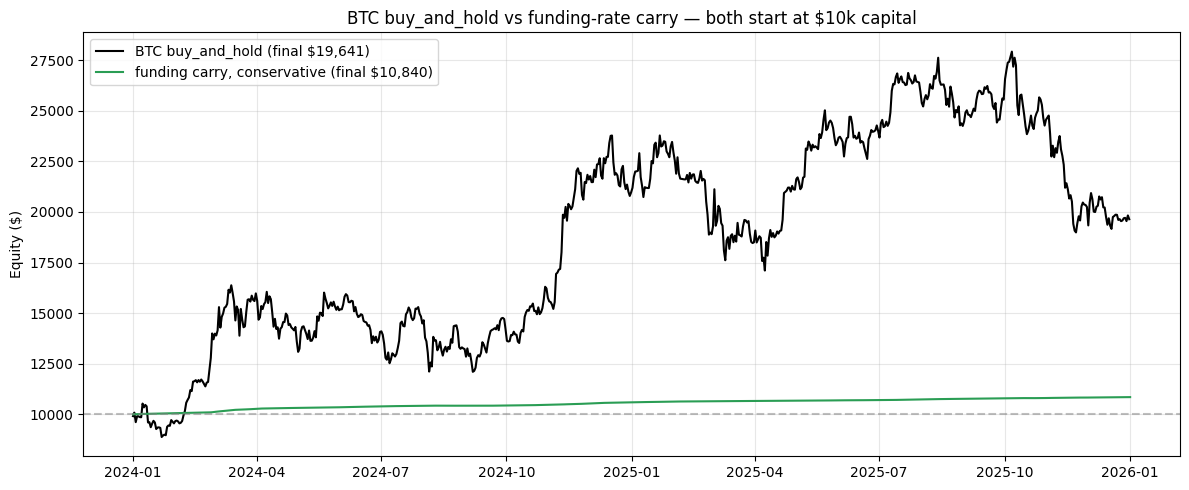

BTC buy_and_hold:    final $19,640.70, max DD -32.02%
Funding carry (cons): final $10,840.17, max DD -0.04%


In [6]:
# Carry equity curve at the conservative scenario, per $10k initial capital
# (proportional to net_cash on $20k → halve it for $10k).
carry_factor = 0.5  # $10k of $20k notional pair
f['carry_equity'] = 10_000 + (f['cumulative'] - FEES_TOTAL * 0) * carry_factor
# Actually subtract fees once at the start for fairness
f['carry_equity'] = 10_000 - FEES_TOTAL * carry_factor + f['cumulative'] * carry_factor

spot_eq = spot.copy()
spot_eq['bh_equity'] = 10_000 * (spot_eq['close'] / spot_eq['close'].iloc[0]) * 0.99  # alloc 99%

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spot_eq['timestamp'], spot_eq['bh_equity'], color='black', linewidth=1.5,
        label=f'BTC buy_and_hold (final ${spot_eq["bh_equity"].iloc[-1]:,.0f})')
ax.plot(f['timestamp'], f['carry_equity'], color='#2a9d54', linewidth=1.5,
        label=f'funding carry, conservative (final ${f["carry_equity"].iloc[-1]:,.0f})')
ax.axhline(10_000, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Equity ($)')
ax.set_title('BTC buy_and_hold vs funding-rate carry — both start at $10k capital')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Drawdown of each
def maxdd(s):
    return (s / s.cummax() - 1).min()

print(f'BTC buy_and_hold:    final ${spot_eq["bh_equity"].iloc[-1]:,.2f}, max DD {maxdd(spot_eq["bh_equity"]):.2%}')
print(f'Funding carry (cons): final ${f["carry_equity"].iloc[-1]:,.2f}, max DD {maxdd(f["carry_equity"]):.2%}')

## Takeaways

**1. The carry is real but smaller than the headline number suggests.** Gross APR on notional is healthy — what matters is APR on *capital required*, which is roughly half (with no leverage) or ~two-thirds (with moderate leverage). The aggressive 5x leverage case looks great on paper but introduces real liquidation risk.

**2. Funding compresses over time.** Look at the per-quarter chart. The early quarters of the bull market (when retail floods in long) have the fattest funding rates. As the trade gets more crowded, rates drift toward zero. *This is exactly the alpha-decay everyone warns about — you can see it on a chart.*

**3. The carry trade and buy-and-hold answer different questions.** BTC buy-and-hold is a directional bet that paid handsomely in a bull market. The carry trade is closer to a market-neutral yield product — the right comparison isn't "did it beat BTC?" (it didn't, and that's not the point) but "did it beat T-bills / stablecoin yields / on-chain lending APRs?" That's a *much* closer call.

**4. The honest verdict.** Was the carry profitable in this period? Yes, gross. After realistic frictions in the conservative scenario, also yes — but the net APR is no longer impressive when you factor in operational complexity (managing two legs, monitoring liquidation, rebalancing, basis risk during big moves). For a well-capitalized retail trader the trade is *executable but unspectacular*.

**5. The structural appeal stands.** Unlike trend-following or mean-reversion, the carry doesn't need to predict price direction. It needs the perp's funding mechanism to keep working as designed, which it has for years across multiple market regimes. That's a different category of risk than "will my model parameters generalize?"

## What this experiment doesn't capture

- **Basis risk during leverage flush events.** When BTC gaps hard, the perp can detach from spot for minutes to hours. The delta-neutral hedge isn't actually neutral during those windows. This is the trade's real failure mode and it's invisible in 8h funding data.
- **Funding events vs spot mark price drift.** I assumed perfect rebalancing of notional after each event. In reality the spot leg's value drifts up/down between events, so the hedge ratio gets stale.
- **Cross-margin efficiency.** A pro trader using portfolio margin needs less capital than the simple 2N model. That moves the APR upward.

These are M3-out-of-scope and would belong in a deeper version of this analysis. The point of this experiment was to check whether the *headline thesis* is alive. It is — barely.

## Closing the strategy lab

Three families of strategies tested. None beat buy-and-hold on this two-year BTC sample, but their failure modes are completely different:

  - **Trend (MA)**: bets in the right direction but with on/off timing that costs the rebounds
  - **Mean-revert (Bollinger)**: smaller swings, fewer trades, lower drawdowns, lower returns
  - **Carry (funding)**: market-neutral yield, decaying, capital-inefficient, but real

E5 will look at the *meta*-questions across all four experiments: how parameter-sensitive everything was, how much fees actually mattered, and the punchline — what does this say about retail crypto quant?